# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Anggun Sulis Setyawan
- Email: sul191120@gmail.com
- Id Dicoding: sulbae

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import joblib

from sqlalchemy import create_engine 

### Menyiapkan data yang akan diguankan

## Data Understanding

### Load Data

In [5]:
df = pd.read_csv('https://raw.githubusercontent.com/Sulbae/Student-s-Performances-Dashboard/refs/heads/main/students_data.csv', delimiter=';')

df.head().T

,0,1,2,3,4
Marital status,1,1,1,1,2
Application mode,17,15,1,17,39
Application order,5,1,5,2,1
Course,171,9254,9070,9773,8014
Daytime/evening attendance\t,1,1,1,1,0
Previous qualification,1,1,1,1,1
Previous qualification (grade),122.0,160.0,122.0,122.0,100.0
Nacionality,1,1,1,1,1
Mother's qualification,19,1,37,38,37
Father's qualification,12,3,37,37,38


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

Keterangan:
| # | Column | Non-Null Count | Dtype | Description |
|---|--------|--------------|-----|---|  
| 0 | Marital Status | 4424 non-null |  int64 |  |
| 1 | Application Mode | 4424 non-null | int64 |  |
| 2 | Application Order | 4424 non-null |  int64 |  |
| 3 | Course | 4424 non-null | int64 |  |
| 4 | Daytime/evening attendance | 4424 non-null | int64 |  |
| 5 | Previous qualification | 4424 non-null | int64 |  |
| 6 | Previous qualification (grade) | 4424 non-null | float64 |  |
| 7 | Nationality | 4424 non-null | int64 |  |
| 8 | Mother's qualification | 4424 non-null | int64 |  |
| 9 | Father's qualification | 4424 non-null | int64 |  |
| 10 | Mother's occupation | 4424 non-null | int64 |  |
| 11 | Father's occupation | 4424 non-null | int64 |  |
| 12 | Admission grade | 4424 non-null | float64 |  |
| 13 | Displaced | 4424 non-null | int64 |  |
| 14 | Educational special needs | 4424 non-null | int64 |  |
| 15 | Debtor | 4424 non-null | int64 |  |
| 16 | Tuition fees up to date | 4424 non-null | int64 |  |
| 17 | Gender | 4424 non-null | int64 |  |
| 18 | Scholarship holder | 4424 non-null | int64 |  |
| 19 | Age at enrollment | 4424 non-null | int64 |  |
| 20 | International | 4424 non-null | int64 |  |
| 21 | Curricular units 1st sem (credited) | 4424 non-null | int64 |  |
| 22 | Curricular units 1st sem (enrolled) | 4424 non-null | int64 |  |
| 23 | Curricular units 1st sem (evaluations) | 4424 non-null | int64 |  |
| 24 | Curricular units 1st sem (approved) | 4424 non-null | int64 |  |
| 25 | Curricular units 1st sem (grade) | 4424 non-null | float64 |  |
| 26 | Curricular units 1st sem (without evaluations) | 4424 non-null | int64 |  |
| 27 | Curricular units 2st sem (credited) | 4424 non-null | int64 |  |
| 28 | Curricular units 2st sem (enrolled) | 4424 non-null | int64 |  |
| 29 | Curricular units 2st sem (evaluations) | 4424 non-null | int64 |  |
| 30 | Curricular units 2st sem (approved) | 4424 non-null | int64 |  |
| 31 | Curricular units 2st sem (grade) | 4424 non-null | float64 |  |
| 32 | Curricular units 2st sem (without evaluations) | 4424 non-null | int64 |  |
| 33 | Unemployment rate | 4424 non-null | float64 |  |
| 34 | Inflation | 4424 non-null | float64 |  |
| 35 | GDP | 4424 non-null | float64 |  |
| 36 | Target | 4424 non-null | object |  |

### Raw Data Exploration

#### Cek Kelengkapan Data

In [9]:
print('Missing values:', df.isnull().sum().sum())

print('Duplicate values:', df.duplicated().sum())

Missing values: 0
Duplicate values: 0


#### Cek Distribusi Data

##### Kolom Fitur

In [10]:
# Kolom Fitur
features = df.columns[:-1]

C:\Users\ACER\AppData\Local\Temp\ipykernel_30964\216070777.py:14: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\ACER\.conda\envs\data-science\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


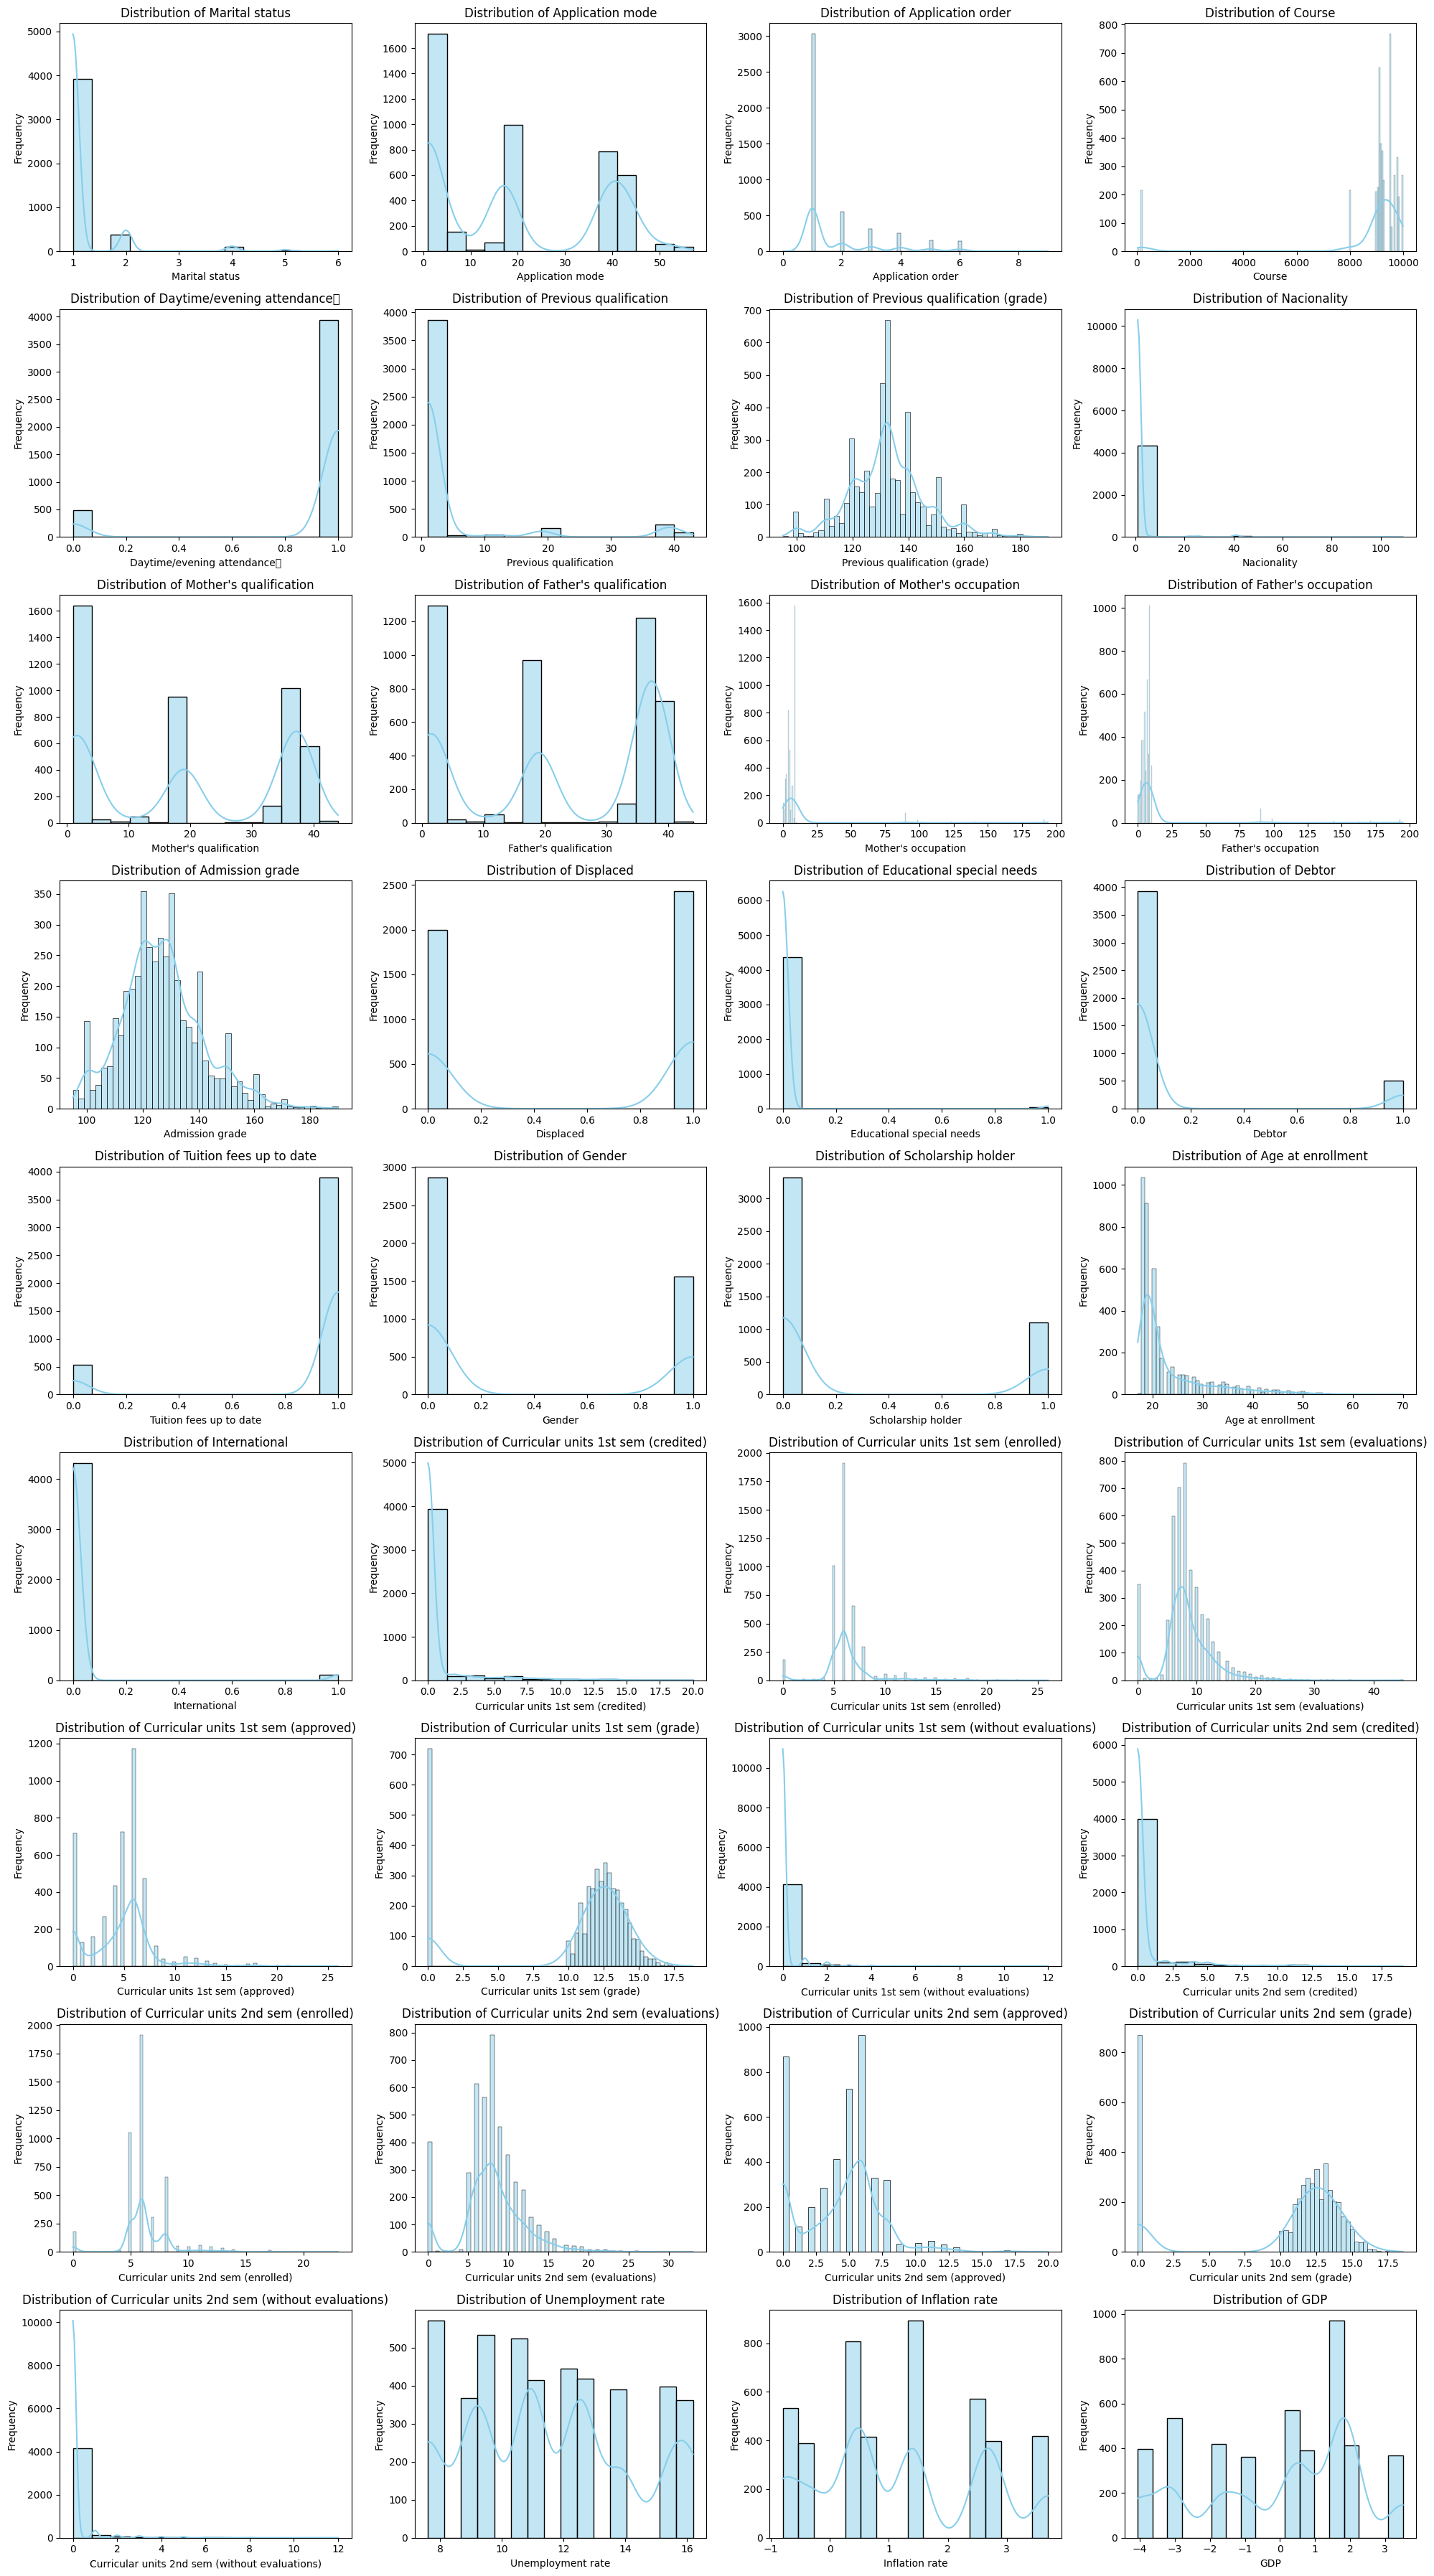

In [17]:
# Distribusi data
n_cols = len(features)
n_rows = (n_cols + 2) // 4

fig, axes = plt.subplots(n_rows, 4, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for idx, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[idx], color='skyblue')
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_30964\955607235.py:14: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\ACER\.conda\envs\data-science\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


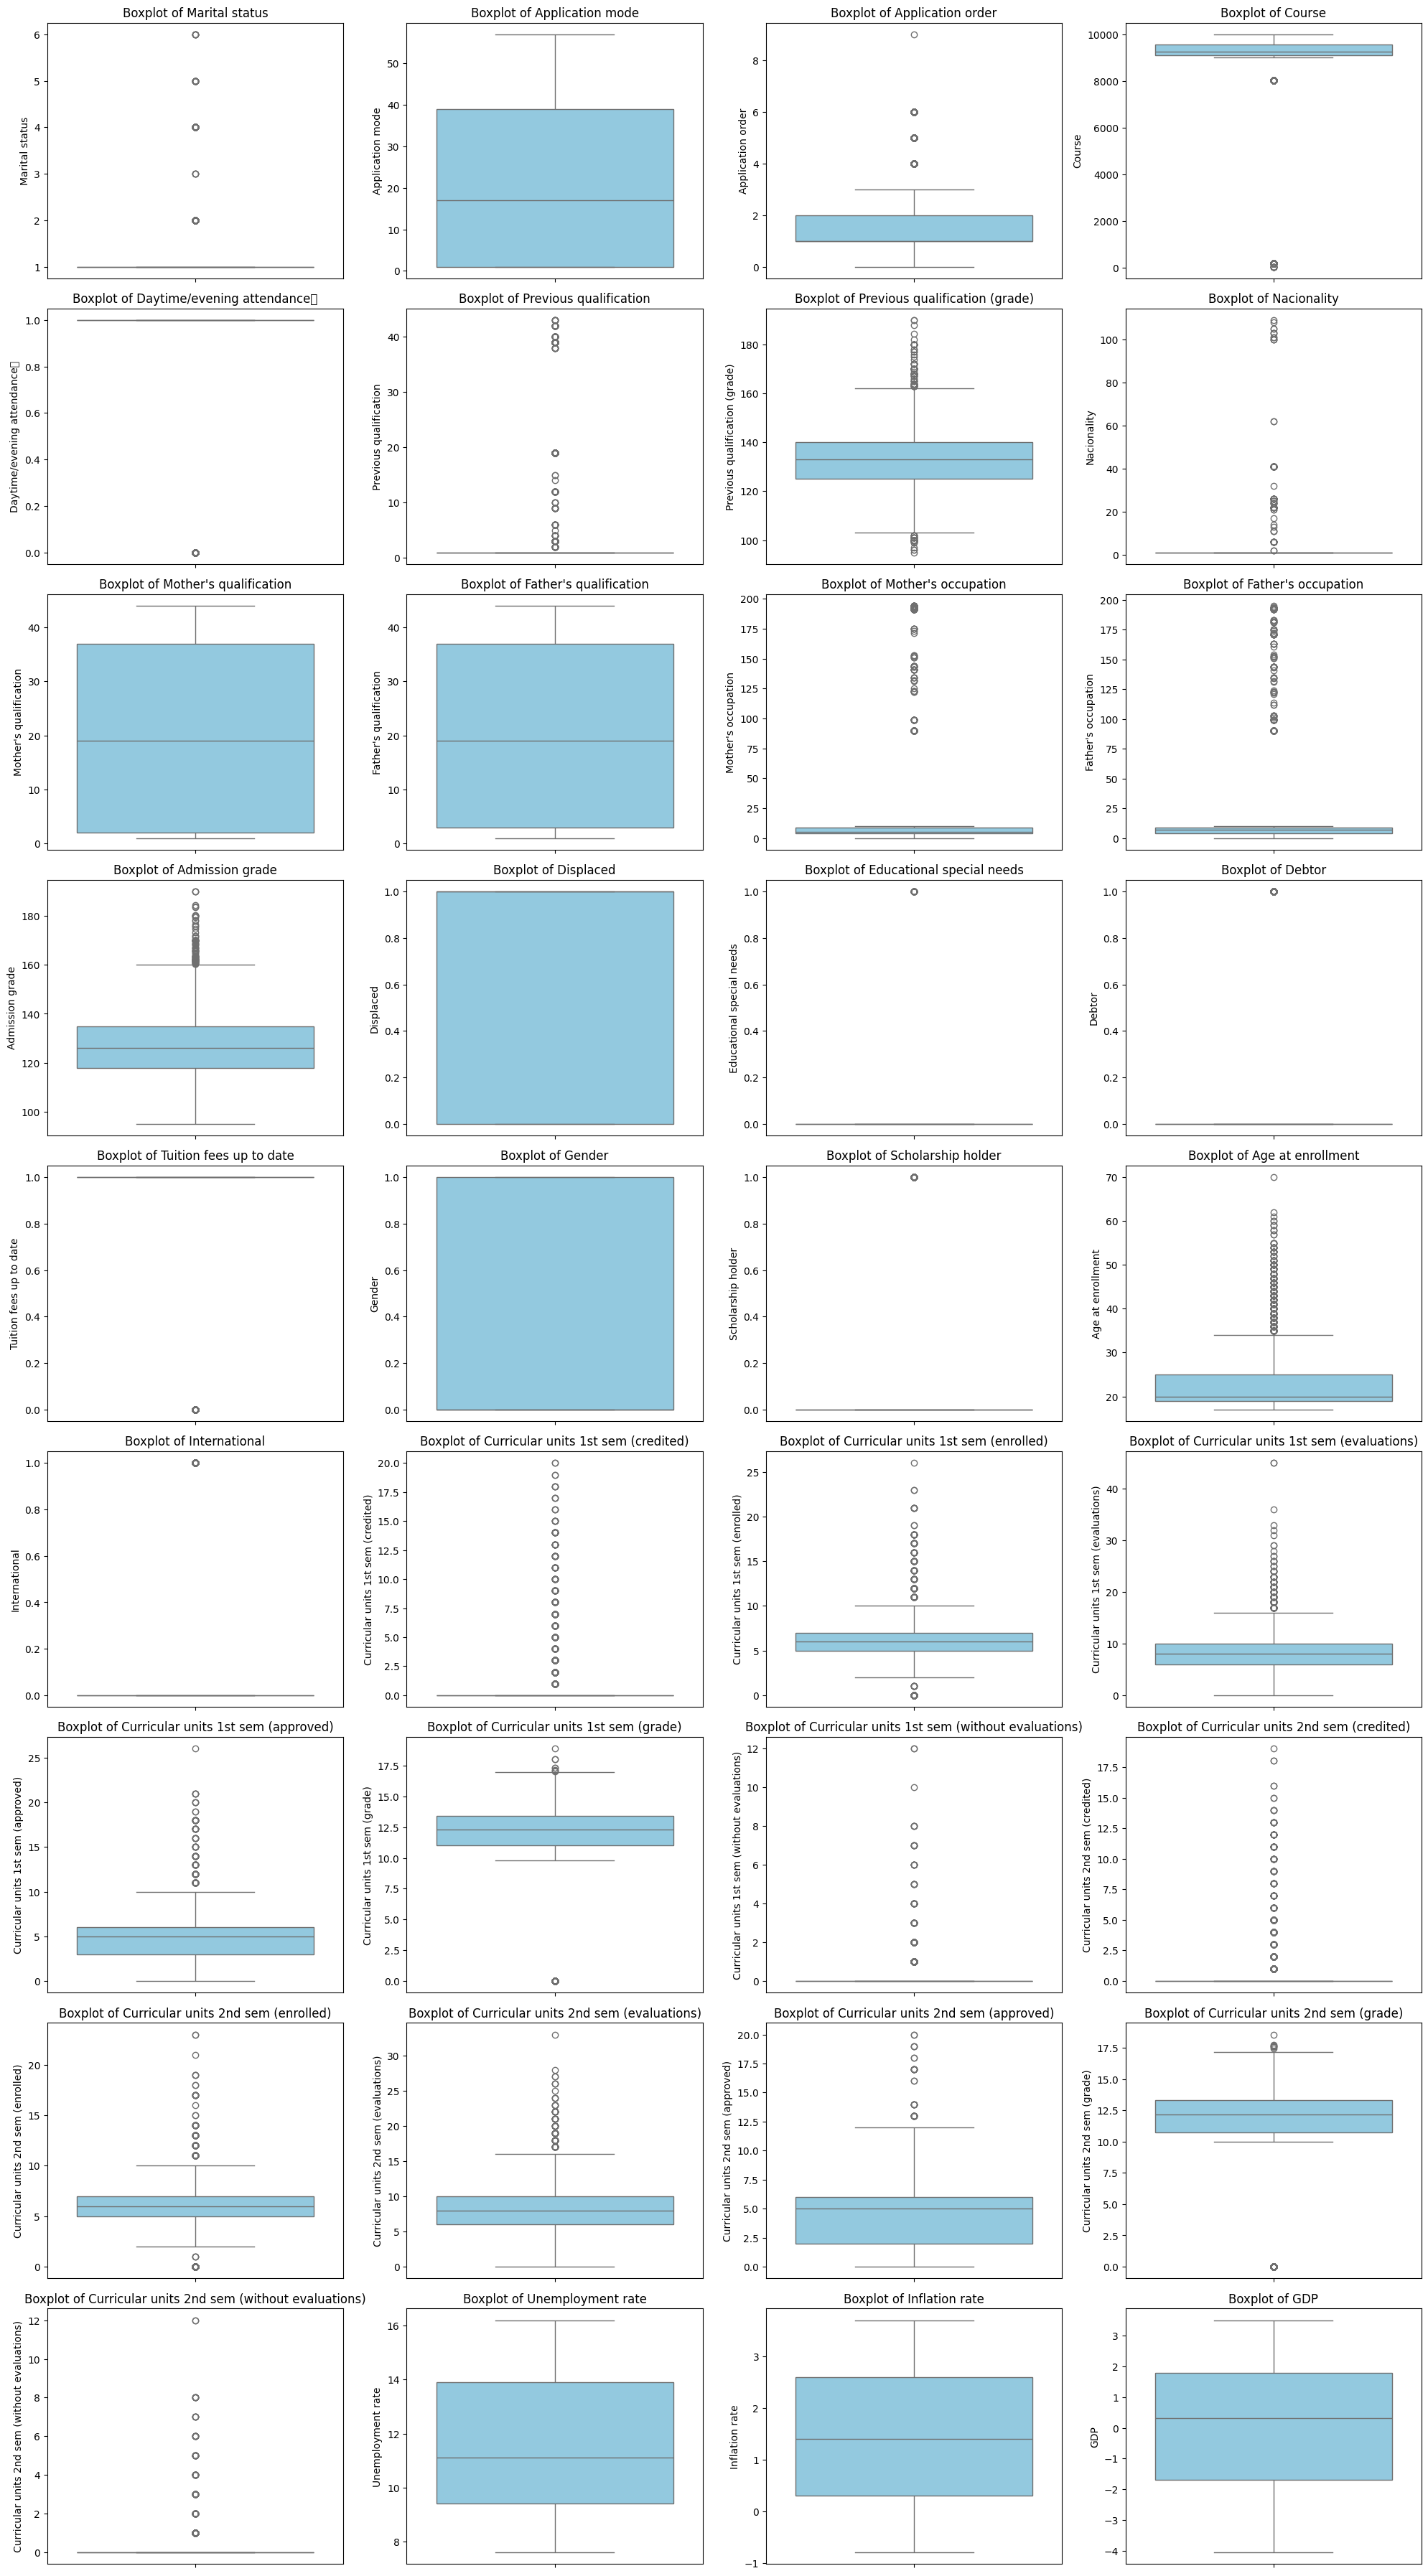

In [15]:
# Periksa outlier
n_cols = len(features)
n_rows = (n_cols + 2) // 4

fig, axes = plt.subplots(n_rows, 4, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for idx, col in enumerate(features):
    sns.boxplot(data=df[col], ax=axes[idx], color='skyblue')
    axes[idx].set_title(f'Boxplot of {col}')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel(col)

plt.tight_layout()
plt.show()

##### Kolom Target

In [18]:
target = df.columns[-1]

C:\Users\ACER\AppData\Local\Temp\ipykernel_30964\4062630300.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target, palette='Set1')


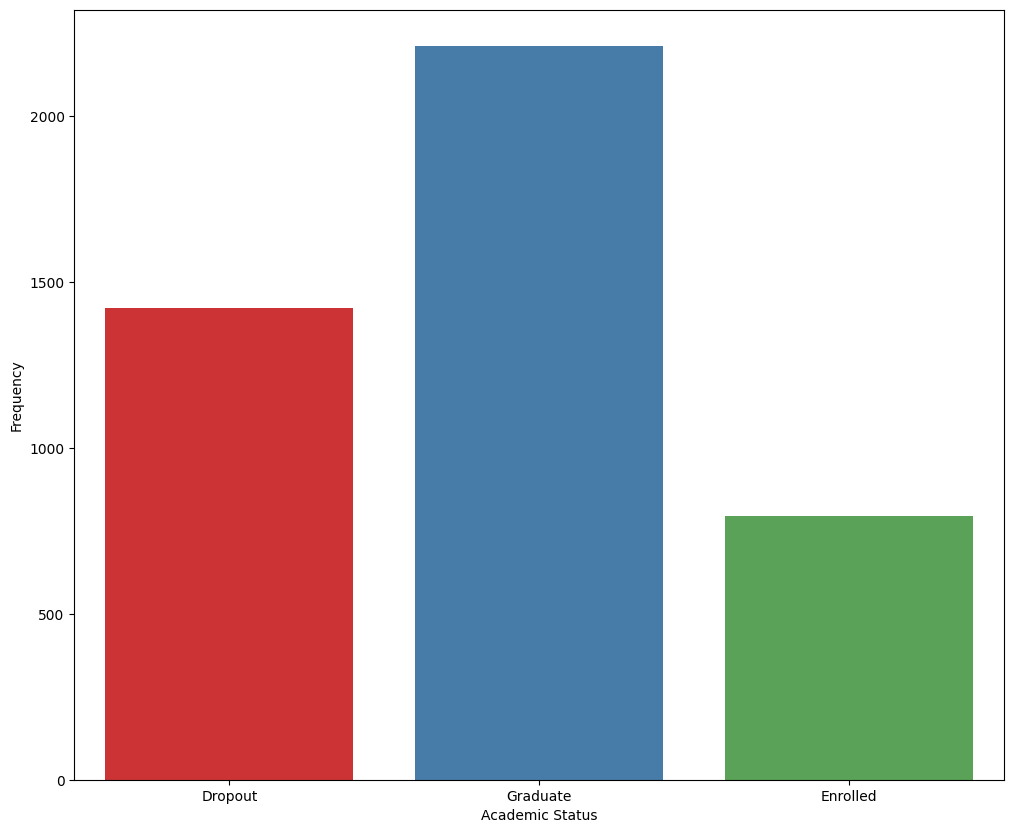

In [27]:
plt.figure(figsize=(12, 10))
sns.countplot(data=df, x=target, palette='Set1')
plt.title('')
plt.xlabel('Academic Status')
plt.ylabel('Frequency')
plt.show()

## Data Preparation / Preprocessing

## Modeling

## Evaluation